In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def f(t, y):
    return -1000 * y + 3000 - 2000 * np.exp(-t)

def analytical_solution(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.002 * np.exp(-t)

In [8]:
def forward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0

    for i in range(1, len(t_values)):
        y_values[i] = y_values[i - 1] + h * f(t_values[i - 1], y_values[i - 1])

    return t_values, y_values

y0 = 0
t0 = 0
tf = 30

step_sizes = [0.1, 0.01, 0.001, 0.00001]

Step size: 0.1


<ipython-input-7-481b2333ef43>:2: RuntimeWarning: overflow encountered in double_scalars
  return -1000 * y + 3000 - 2000 * np.exp(-t)
<ipython-input-8-e3e0a90a5d47>:7: RuntimeWarning: invalid value encountered in double_scalars
  y_values[i] = y_values[i - 1] + h * f(t_values[i - 1], y_values[i - 1])


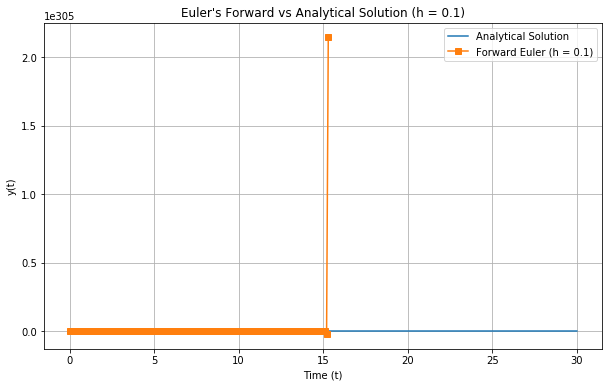

Step size: 0.01


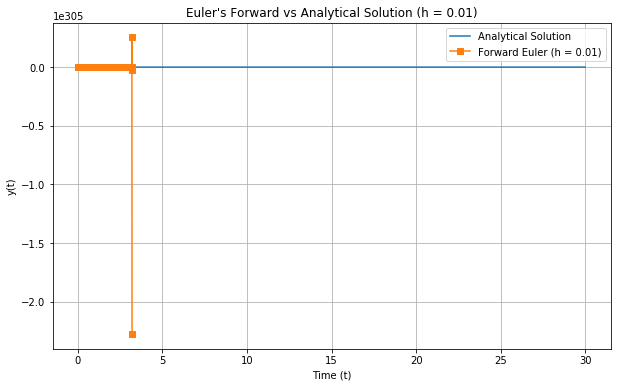

Step size: 0.001


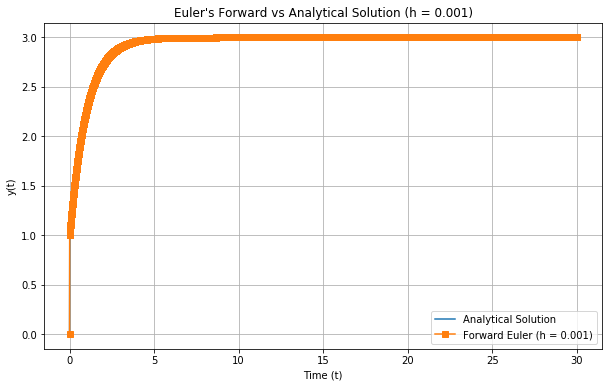

Step size: 1e-05


/opt/conda/lib/python3.8/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


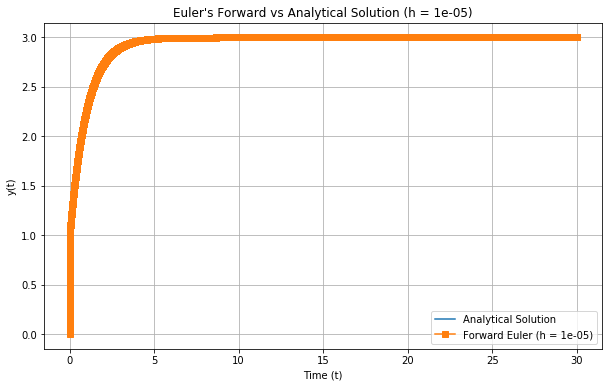

In [9]:
t_exact = np.linspace(t0, tf, 5000)
y_exact = analytical_solution(t_exact)

for h in step_sizes:
    print(f"Step size: {h}")

    t_values_fe, y_values_fe = forward_euler(f, y0, t0, tf, h)

    plt.figure(figsize=(10, 6))
    plt.plot(t_exact, y_exact, label='Analytical Solution')
    plt.plot(t_values_fe, y_values_fe, 's-', label=f'Forward Euler (h = {h})')

    plt.xlabel('Time (t)')
    plt.ylabel('y(t)')
    plt.title(f"Euler's Forward vs Analytical Solution (h = {h})")
    plt.legend()
    plt.grid(True)
    plt.show()